In [ ]:
pip install optuna


In [ ]:
import optuna

In [ ]:
import pandas as pd

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ground_truth.csv to ground_truth (1).csv
Saving observations.csv to observations (1).csv


In [ ]:
# 1. Count Minimum Sequence Length from Observations
# Load the data
obs_df = pd.read_csv("observations.csv")
gt_df = pd.read_csv("ground_truth.csv")

# Get sequence lengths per tracklet
seq_lengths = obs_df.groupby("Track_ID").size()
seq_len  = seq_lengths.min()

print("Minimum sequence length (per Track_ID):", seq_len)


Minimum sequence length (per Track_ID): 4


In [ ]:
# === Build dataset ===
def build_tracklets(obs_df, gt_df, seq_len):
    all_tracklets = []
    all_targets = []
    scaler_az_el = MinMaxScaler()
    scaler_az_el.fit(obs_df[['Azimuth', 'Elevation']])

    for track_id in gt_df['Track_ID']:
        track_obs = obs_df[obs_df['Track_ID'] == track_id].sort_values('MJD')
        if len(track_obs) < seq_len:
            continue
        az_el = scaler_az_el.transform(track_obs[['Azimuth', 'Elevation']])
        mjd = track_obs['MJD'].values
        mid_mjd = mjd[len(mjd) // 2]
        delta_t = mjd - mid_mjd
        sequence = np.hstack([az_el, delta_t.reshape(-1, 1)])
        sequence = sequence[:seq_len]
        all_tracklets.append(sequence)
        all_targets.append(gt_df[gt_df['Track_ID'] == track_id].iloc[0, 1:].values.astype(np.float32))

    return np.array(all_tracklets), np.array(all_targets), scaler_az_el

In [ ]:
# === Dataset class ===
class OrbitDataset(Dataset):
    def __init__(self, tracklets, targets):
        self.tracklets = torch.tensor(tracklets, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.tracklets)

    def __getitem__(self, idx):
        return self.tracklets[idx], self.targets[idx]


In [ ]:
# === Run training ===
tracklets, targets, scaler = build_tracklets(obs_df, gt_df, seq_len)
dataset = OrbitDataset(tracklets, targets)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4)

In [ ]:
def objective(trial):
    # --- Suggest hyperparameters ---
    hidden_size = trial.suggest_int('hidden_size', 32, 256)
    num_layers = trial.suggest_int('num_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.0, 0.5)
    lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)

    # --- Define the model ---
    class TunedLSTM(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = nn.LSTM(input_size=3,
                                hidden_size=hidden_size,
                                num_layers=num_layers,
                                dropout=dropout,
                                batch_first=True,
                                bidirectional=True)
            self.fc = nn.Sequential(
                nn.Linear(hidden_size * 2, 128),
                nn.ReLU(),
                nn.Linear(128, 6)
            )
        def forward(self, x):
            lstm_out, _ = self.lstm(x)
            mid_idx = x.shape[1] // 2
            return self.fc(lstm_out[:, mid_idx, :])

    model = TunedLSTM()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # --- Short training for tuning ---
    model.train()
    for epoch in range(5):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    # --- Evaluate on validation (test_loader) ---
    model.eval()
    all_preds = []
    all_truths = []
    with torch.no_grad():
        for xb, yb in test_loader:
            pred = model(xb)
            all_preds.append(pred.numpy())
            all_truths.append(yb.numpy())

    preds = np.vstack(all_preds)
    truths = np.vstack(all_truths)

    rmse = np.sqrt(np.mean((truths - preds)**2))  # overall RMSE
    return rmse

In [ ]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)  # increase to 100+ for final

print("Best parameters found:", study.best_params)
print("Best validation RMSE:", study.best_value)


[I 2025-07-24 21:13:03,447] A new study created in memory with name: no-name-6b6dae46-d0f9-44d5-b319-e64dd716ff4e
/tmp/ipython-input-11-2947512808.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
[I 2025-07-24 21:13:15,331] Trial 0 finished with value: 1384.59375 and parameters: {'hidden_size': 123, 'num_layers': 3, 'dropout': 0.23304872460029136, 'lr': 0.007272171708266122}. Best is trial 0 with value: 1384.59375.
/tmp/ipython-input-11-2947512808.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
[I 2025-07-24 21:13:26,393] Trial 1 finished with value: 13566.09375 and pa

Best parameters found: {'hidden_size': 220, 'num_layers': 2, 'dropout': 0.06190099593160911, 'lr': 0.008101627415340037}
Best validation RMSE: 1371.12548828125


In [ ]:
optuna.visualization.plot_optimization_history(study).show()
optuna.visualization.plot_param_importances(study).show()


In [ ]:
# Final Model Using These Hyperparameters
class FinalLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=3,
            hidden_size=111,
            num_layers=1,
            dropout=0.4161573283646921,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Sequential(
            nn.Linear(111 * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        mid_idx = x.shape[1] // 2
        return self.fc(lstm_out[:, mid_idx, :])

In [ ]:
losses = []

In [ ]:
model = FinalLSTM()
optimizer = torch.optim.Adam(model.parameters(), lr=0.004710731267881119)
criterion = nn.MSELoss()

# Final training
for epoch in range(100):  # Train for more epochs
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} - Loss: {total_loss / len(train_loader):.4f}")
    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1} - Loss: {avg_loss:.4f}")


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning:

dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4161573283646921 and num_layers=1



Epoch 1 - Loss: 260671283.6303
Epoch 1 - Loss: 260671283.6303
Epoch 2 - Loss: 88719746.4202
Epoch 2 - Loss: 88719746.4202
Epoch 3 - Loss: 9644649.2022
Epoch 3 - Loss: 9644649.2022
Epoch 4 - Loss: 2420664.8114
Epoch 4 - Loss: 2420664.8114
Epoch 5 - Loss: 2320498.0780
Epoch 5 - Loss: 2320498.0780
Epoch 6 - Loss: 2320660.2207
Epoch 6 - Loss: 2320660.2207
Epoch 7 - Loss: 2322382.4554
Epoch 7 - Loss: 2322382.4554
Epoch 8 - Loss: 2315749.8892
Epoch 8 - Loss: 2315749.8892
Epoch 9 - Loss: 2320049.9131
Epoch 9 - Loss: 2320049.9131
Epoch 10 - Loss: 2327574.7357
Epoch 10 - Loss: 2327574.7357
Epoch 11 - Loss: 2325738.8130
Epoch 11 - Loss: 2325738.8130
Epoch 12 - Loss: 2335413.5286
Epoch 12 - Loss: 2335413.5286
Epoch 13 - Loss: 2322683.5701
Epoch 13 - Loss: 2322683.5701
Epoch 14 - Loss: 2320269.5186
Epoch 14 - Loss: 2320269.5186
Epoch 15 - Loss: 2331856.8739
Epoch 15 - Loss: 2331856.8739
Epoch 16 - Loss: 2327884.4986
Epoch 16 - Loss: 2327884.4986
Epoch 17 - Loss: 2329768.4347
Epoch 17 - Loss: 23297

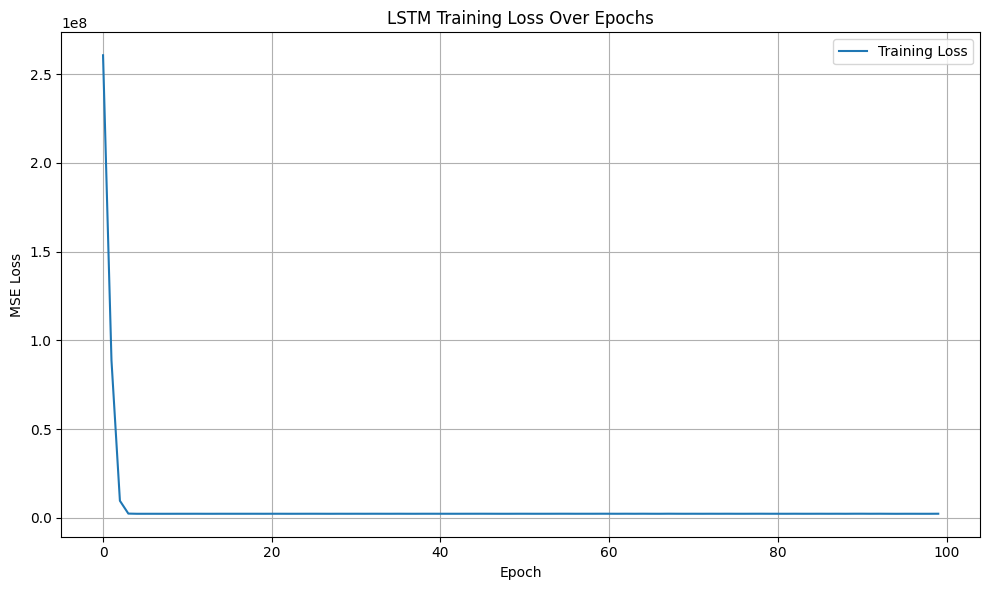

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training Loss Over Epochs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
model.eval()
all_preds, all_truths = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb)
        all_preds.append(preds.numpy())
        all_truths.append(yb.numpy())

preds = np.vstack(all_preds)
truths = np.vstack(all_truths)

mae = np.mean(np.abs(truths - preds), axis=0)
rmse = np.sqrt(np.mean((truths - preds) ** 2, axis=0))
mean_truth = np.mean(np.abs(truths), axis=0)
percent_mae = 100 * mae / mean_truth
percent_rmse = 100 * rmse / mean_truth

In [ ]:
# Display table
df = pd.DataFrame({'MAE': mae, 'RMSE': rmse}, index=['r_x', 'r_y', 'r_z', 'v_x', 'v_y', 'v_z']).T
print("\n=== Error Table (MAE and RMSE) ===")
print(df.to_string(float_format="{:8.3f}".format))

# Detailed breakdown
labels = ['x', 'y', 'z', 'vx', 'vy', 'vz']
units = ['km', 'km', 'km', 'km/s', 'km/s', 'km/s']
print("\n=== Detailed Error Breakdown ===")
for i in range(6):
    print(f"{labels[i]} MAE:  {mae[i]:10.2f} {units[i]:<5}  ({percent_mae[i]:8.2f}%)")
    print(f"{labels[i]} RMSE: {rmse[i]:10.2f} {units[i]:<5}  ({percent_rmse[i]:8.2f}%)")


=== Error Table (MAE and RMSE) ===
          r_x      r_y      r_z      v_x      v_y      v_z
MAE  1279.903 2627.830   44.463    3.100    2.328    0.276
RMSE 1481.612 3016.013   92.844    3.108    2.331    0.324

=== Detailed Error Breakdown ===
x MAE:     1279.90 km     (    3.34%)
x RMSE:    1481.61 km     (    3.87%)
y MAE:     2627.83 km     (   15.18%)
y RMSE:    3016.01 km     (   17.42%)
z MAE:       44.46 km     (   50.15%)
z RMSE:      92.84 km     (  104.73%)
vx MAE:        3.10 km/s   (  246.54%)
vx RMSE:       3.11 km/s   (  247.20%)
vy MAE:        2.33 km/s   (   83.52%)
vy RMSE:       2.33 km/s   (   83.63%)
vz MAE:        0.28 km/s   (  566.96%)
vz RMSE:       0.32 km/s   (  666.60%)


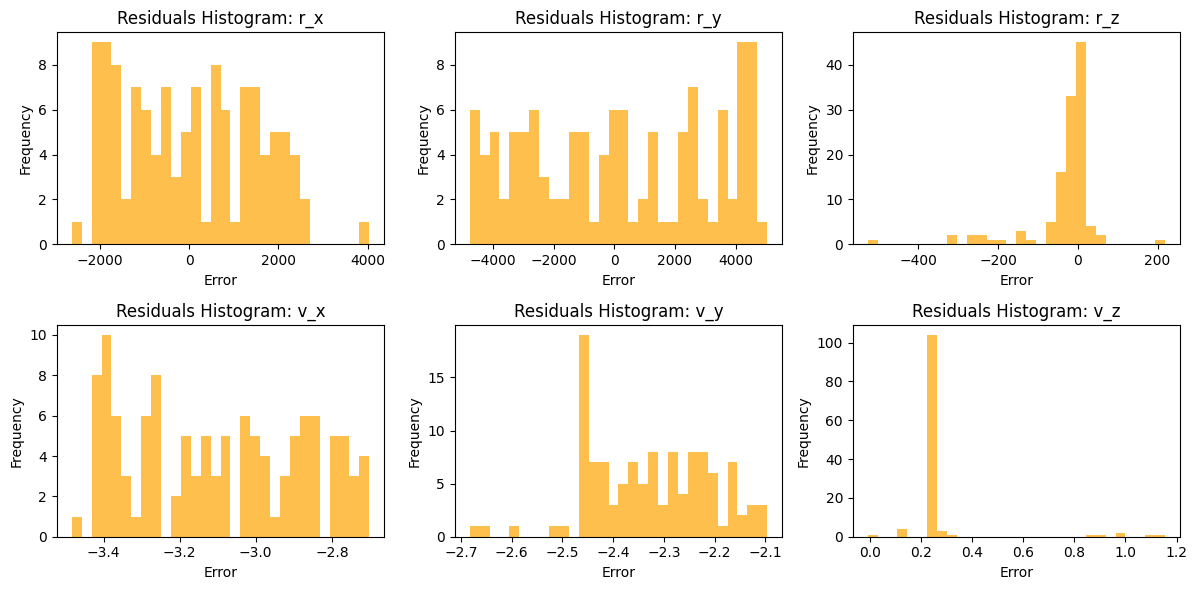

In [ ]:
# Residual Histogram
residuals = truths - preds
labels_full = ['r_x', 'r_y', 'r_z', 'v_x', 'v_y', 'v_z']

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.hist(residuals[:, i], bins=30, alpha=0.7, color='orange')
    plt.title(f"Residuals Histogram: {labels_full[i]}")
    plt.xlabel("Error")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


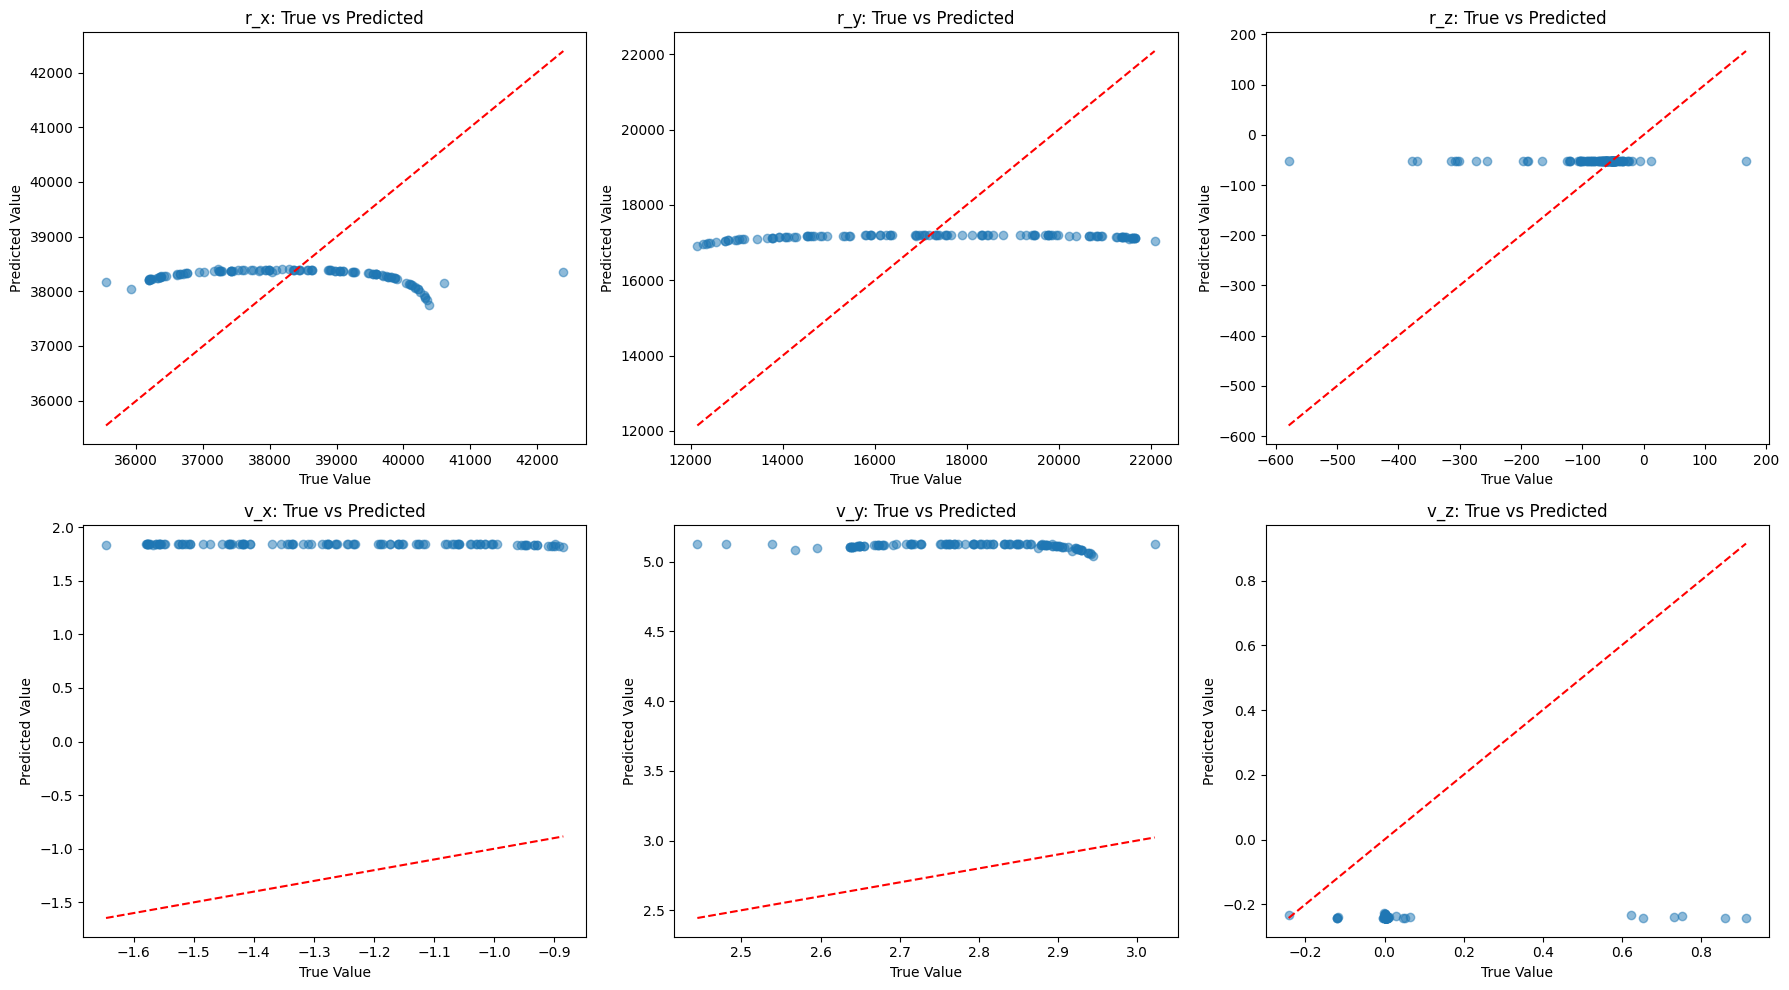

In [ ]:
# True vs Predicted Scatter Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(6):
    axes[i].scatter(truths[:, i], preds[:, i], alpha=0.5)
    axes[i].plot([min(truths[:, i]), max(truths[:, i])],
                 [min(truths[:, i]), max(truths[:, i])], 'r--')
    axes[i].set_title(f"{labels_full[i]}: True vs Predicted")
    axes[i].set_xlabel("True Value")
    axes[i].set_ylabel("Predicted Value")

plt.tight_layout()
plt.show()


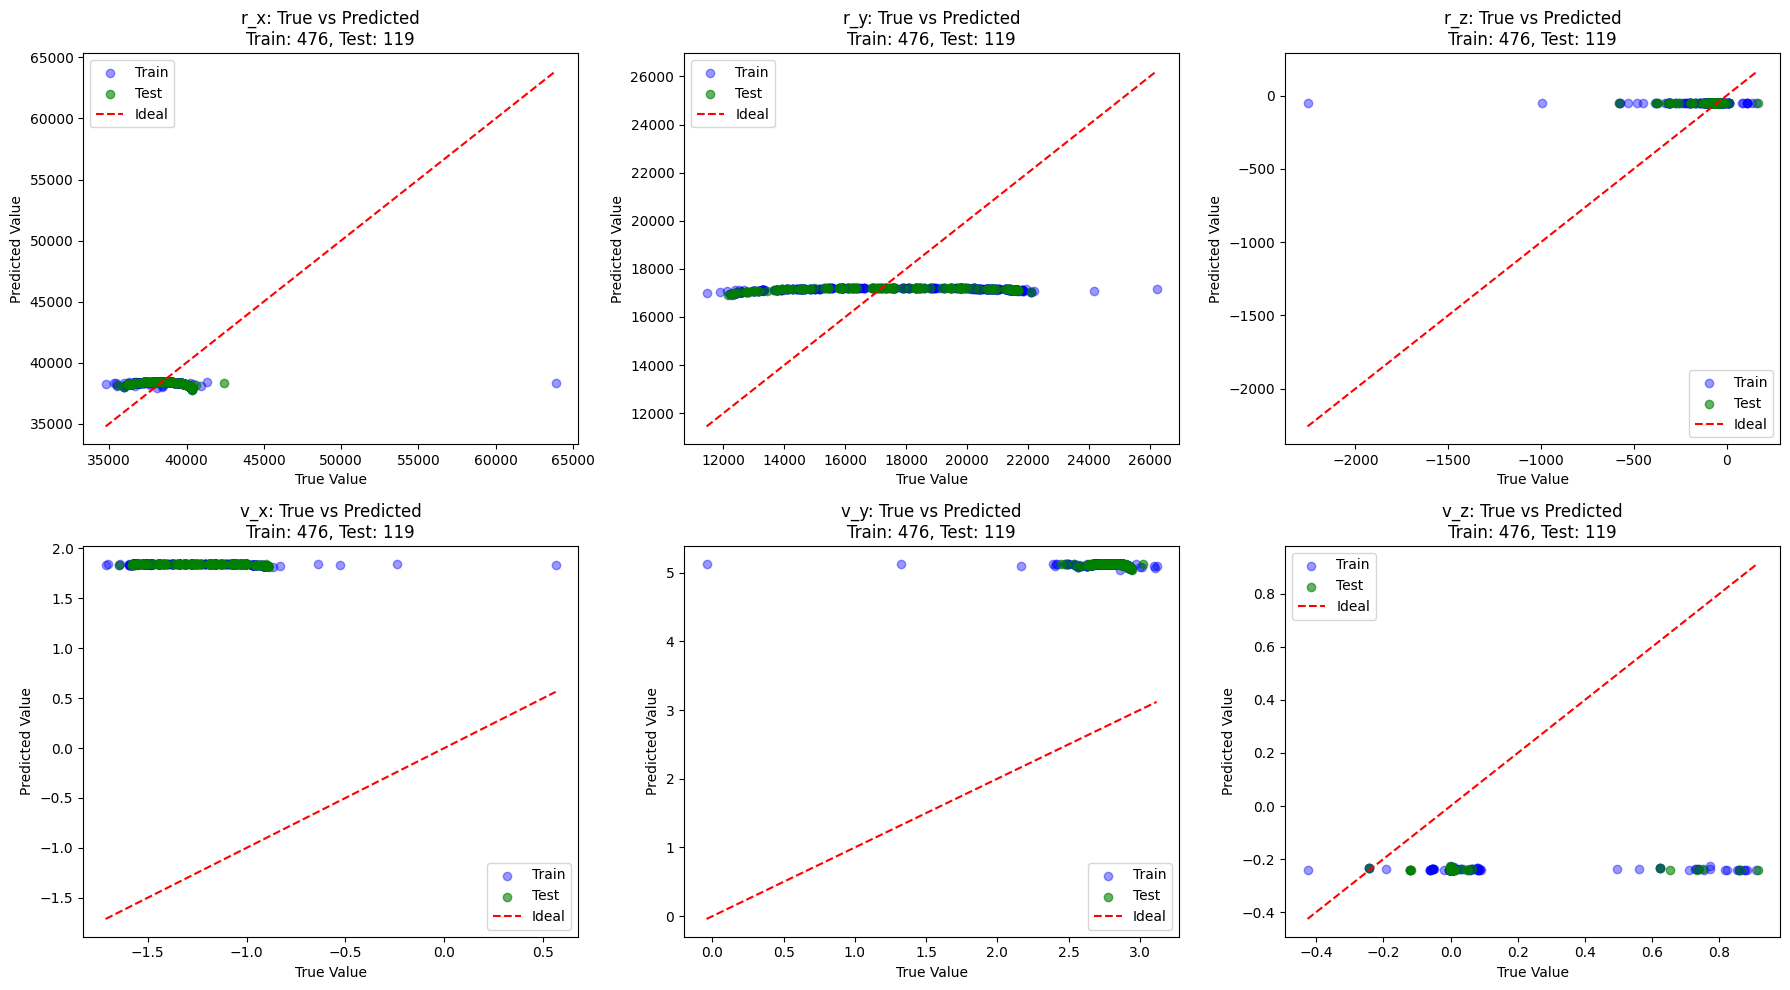

In [ ]:
# === LSTM True vs Predicted Scatter Plot: Train vs Test Separately ===
model.eval()

# Predictions on test set
all_preds_test, all_truths_test = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb)
        all_preds_test.append(preds.numpy())
        all_truths_test.append(yb.numpy())

truths_test = np.vstack(all_truths_test)
preds_test = np.vstack(all_preds_test)

# Predictions on train set
all_preds_train, all_truths_train = [], []
with torch.no_grad():
    for xb, yb in train_loader:
        preds = model(xb)
        all_preds_train.append(preds.numpy())
        all_truths_train.append(yb.numpy())

truths_train = np.vstack(all_truths_train)
preds_train = np.vstack(all_preds_train)

# Plotting
labels_full = ['r_x', 'r_y', 'r_z', 'v_x', 'v_y', 'v_z']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(6):
    axes[i].scatter(truths_train[:, i], preds_train[:, i], alpha=0.4, color='blue', label='Train')
    axes[i].scatter(truths_test[:, i], preds_test[:, i], alpha=0.6, color='green', label='Test')

    min_val = min(truths_train[:, i].min(), truths_test[:, i].min())
    max_val = max(truths_train[:, i].max(), truths_test[:, i].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')

    axes[i].set_title(f"{labels_full[i]}: True vs Predicted\nTrain: {len(truths_train)}, Test: {len(truths_test)}")
    axes[i].set_xlabel("True Value")
    axes[i].set_ylabel("Predicted Value")
    axes[i].legend()

plt.tight_layout()
plt.show()